# MATH 189 — Group 11

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path


os.makedirs("figures", exist_ok=True)
df = pd.read_csv("ca_aqi_acs_master_county_avg.csv")

## Problem

...

### Problem Statement

...

### Problem Relevance

...

<br><br/>

## Data

...

#### Data Cleaning/Transformation

...

<br><br/>

## Exploratory Data Analysis (EDA) - Note: Im not sure what to include here, or who did work for this

...

#### Visual Analyses

...

## IMPORTANT: Edit this code to actually show the image in the notebook here, i already took it out but also make sure the code is reading csv from github files not local files.

In [ ]:
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
)

ca = counties[counties["STATE_NAME"] == "California"].copy()

df["county_clean"] = df["county"].str.lower().str.strip()
ca["county_clean"] = ca["NAME"].str.lower().str.strip()

merged = ca.merge(df, on="county_clean", how="left")

fig, ax = plt.subplots(figsize=(10, 12))

merged.plot(
    column="avg_bad_aqi_day_pct_2020_2024",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing data"}
)

ax.set_title(
    "Average Percentage of Unhealthy AQI Days by California County (2020–2024)",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()

output_path = "/Users/kashikasharma/Downloads/california_bad_aqi_map.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved map to: {output_path}")

top10 = (
    df.sort_values("avg_bad_aqi_day_pct_2020_2024", ascending=False)
    [["county", "avg_bad_aqi_day_pct_2020_2024"]]
    .head(10)
)

print("\nTop 10 Counties by Bad AQI Percentage:")
print(top10.to_string(index=False))

In [12]:
metric = "avg_bad_aqi_day_pct_2020_2024"

top10 = (
    df.sort_values(metric, ascending=False)
    [["county", metric]]
    .head(10)
    .sort_values(metric, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top10["county"], top10[metric])

ax.set_title("Top 10 California Counties by Bad AQI Day Percentage (2020–2024)")
ax.set_xlabel("Average bad AQI days (%)")
ax.set_ylabel("County")

plt.tight_layout()

output_path = "figures/top10_bad_aqi_counties.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved bar chart to: {output_path}")
print("\nTop 10 counties:")
print(top10.sort_values(metric, ascending=False).to_string(index=False))

Saved bar chart to: figures/top10_bad_aqi_counties.png

Top 10 counties:
        county  avg_bad_aqi_day_pct_2020_2024
San Bernardino                      38.364997
     Riverside                      36.668613
        Tulare                      31.524815
   Los Angeles                      29.986975
          Kern                      29.774684
        Fresno                      21.233625
         Kings                      12.806198
      Imperial                      11.002021
        Plumas                      10.473173
     San Diego                      10.231454


#### Correlational Analysis

...

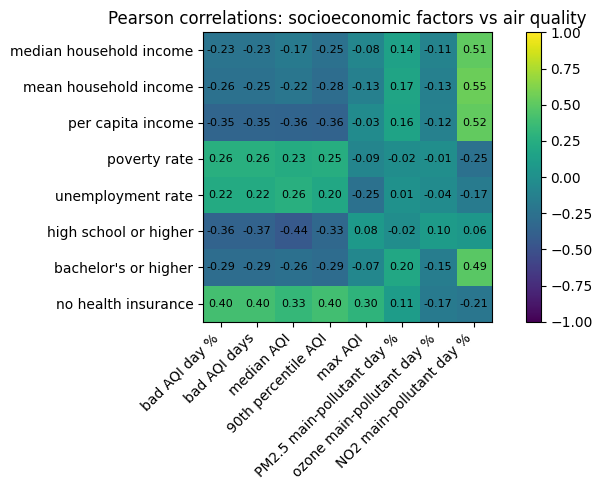

               socio_variable                       air_variable   n  pearson_r  pearson_p  spearman_r  spearman_p
42  pct_high_school_or_higher           avg_median_aqi_2020_2024  53    -0.4422     0.0009     -0.3764      0.0055
56    pct_no_health_insurance      avg_bad_aqi_day_pct_2020_2024  53     0.4032     0.0028      0.4392      0.0010
59    pct_no_health_insurance  avg_aqi_90th_percentile_2020_2024  53     0.3976     0.0032      0.4104      0.0023
40  pct_high_school_or_higher      avg_bad_aqi_day_pct_2020_2024  53    -0.3641     0.0074     -0.2660      0.0542
19          per_capita_income  avg_aqi_90th_percentile_2020_2024  53    -0.3638     0.0074     -0.3746      0.0057
18          per_capita_income           avg_median_aqi_2020_2024  53    -0.3592     0.0083     -0.3474      0.0108
16          per_capita_income      avg_bad_aqi_day_pct_2020_2024  53    -0.3480     0.0107     -0.4539      0.0006
58    pct_no_health_insurance           avg_median_aqi_2020_2024  53     0.3342 

In [15]:
outputDir = Path(".")

countyYearFile = Path("ca_aqi_acs_master_county_year.csv")
countyAvgFile  = Path("ca_aqi_acs_master_county_avg.csv")
dataDictFile   = Path("ca_aqi_acs_data_dictionary.csv")
missingFile    = Path("ca_aqi_acs_missingness_report.csv")

allCorrOut = outputDir / "correlation_results_all.csv"
keyCorrOut = outputDir / "correlation_results_key_pairs.csv"
matrixOut  = outputDir / "correlation_matrix_soc_air.csv"
yearlyOut  = outputDir / "year_by_year_correlation_summary.csv"
summaryOut = outputDir / "correlation_analysis_summary.md"
heatmapOut = outputDir / "figures/correlation_heatmap_soc_air.png"

socioCols = [
    "median_household_income",
    "mean_household_income",
    "per_capita_income",
    "poverty_rate_all_people",
    "unemployment_rate",
    "pct_high_school_or_higher",
    "pct_bachelors_or_higher",
    "pct_no_health_insurance",
]

airCols = [
    "avg_bad_aqi_day_pct_2020_2024",
    "avg_bad_aqi_days_2020_2024",
    "avg_median_aqi_2020_2024",
    "avg_aqi_90th_percentile_2020_2024",
    "avg_max_aqi_2020_2024",
    "avg_pct_days_pm25_main_pollutant_2020_2024",
    "avg_pct_days_ozone_main_pollutant_2020_2024",
    "avg_pct_days_no2_main_pollutant_2020_2024",
]

yearlyAirMap = {
    "avg_bad_aqi_day_pct_2020_2024": "bad_aqi_day_pct",
    "avg_median_aqi_2020_2024": "median_aqi",
    "avg_aqi_90th_percentile_2020_2024": "aqi_90th_percentile",
    "avg_max_aqi_2020_2024": "max_aqi",
    "avg_pct_days_pm25_main_pollutant_2020_2024": "pct_days_pm25_main_pollutant",
    "avg_pct_days_ozone_main_pollutant_2020_2024": "pct_days_ozone_main_pollutant",
}

prettyNames = {
    "median_household_income": "median household income",
    "mean_household_income": "mean household income",
    "per_capita_income": "per capita income",
    "poverty_rate_all_people": "poverty rate",
    "unemployment_rate": "unemployment rate",
    "pct_high_school_or_higher": "high school or higher",
    "pct_bachelors_or_higher": "bachelor's or higher",
    "pct_no_health_insurance": "no health insurance",
    "avg_bad_aqi_day_pct_2020_2024": "bad AQI day %",
    "avg_bad_aqi_days_2020_2024": "bad AQI days",
    "avg_median_aqi_2020_2024": "median AQI",
    "avg_aqi_90th_percentile_2020_2024": "90th percentile AQI",
    "avg_max_aqi_2020_2024": "max AQI",
    "avg_pct_days_pm25_main_pollutant_2020_2024": "PM2.5 main-pollutant day %",
    "avg_pct_days_ozone_main_pollutant_2020_2024": "ozone main-pollutant day %",
    "avg_pct_days_no2_main_pollutant_2020_2024": "NO2 main-pollutant day %",
}


def getCorr(data, xCol, yCol):
    pairData = data[[xCol, yCol]].dropna()
    n = len(pairData)
    if n < 3:
        return None
    pearsonR, pearsonP = stats.pearsonr(pairData[xCol], pairData[yCol])
    spearmanR, spearmanP = stats.spearmanr(pairData[xCol], pairData[yCol])
    return {
        "socio_variable": xCol,
        "air_variable": yCol,
        "n": n,
        "pearson_r": pearsonR,
        "pearson_p": pearsonP,
        "spearman_r": spearmanR,
        "spearman_p": spearmanP,
    }


def addBenjaminiHochberg(results, pCol, outCol):
    ranked = results[pCol].rank(method="first")
    m = results[pCol].notna().sum()
    results[outCol] = (results[pCol] * m / ranked).clip(upper=1)
    results[outCol] = results[outCol].sort_values(ascending=False).cummin()
    return results


def saveScatter(countyAvg, xCol, yCol, fileName):
    plotData = countyAvg[["county", xCol, yCol]].dropna()
    slope, intercept, rVal, pVal, stdErr = stats.linregress(plotData[xCol], plotData[yCol])
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(plotData[xCol], plotData[yCol])
    xLine = np.linspace(plotData[xCol].min(), plotData[xCol].max(), 100)
    yLine = intercept + slope * xLine
    ax.plot(xLine, yLine)
    ax.set_xlabel(prettyNames.get(xCol, xCol))
    ax.set_ylabel(prettyNames.get(yCol, yCol))
    ax.set_title(f"{prettyNames.get(xCol, xCol)} vs {prettyNames.get(yCol, yCol)}")
    ax.text(0.03, 0.97, f"r = {rVal:.2f}\np = {pVal:.4f}", transform=ax.transAxes, va="top")
    fig.tight_layout()
    fig.savefig(outputDir / fileName, dpi=300)
    plt.close(fig)


neededFiles = [countyYearFile, countyAvgFile, dataDictFile, missingFile]
missingFiles = [path for path in neededFiles if not path.exists()]
if missingFiles:
    raise FileNotFoundError(f"Missing cleaned files: {missingFiles}")

countyYear    = pd.read_csv(countyYearFile)
countyAvg     = pd.read_csv(countyAvgFile)
dataDictionary = pd.read_csv(dataDictFile)
missingReport = pd.read_csv(missingFile)

highMissing = missingReport[missingReport["missing_pct"] > 20]
if len(highMissing) > 0:
    print("Warning: some columns have high missingness:")
    print(highMissing[["column", "missing_pct"]])

rows = []
for socioCol in socioCols:
    for airCol in airCols:
        corrRow = getCorr(countyAvg, socioCol, airCol)
        if corrRow is not None:
            rows.append(corrRow)

results = pd.DataFrame(rows)
results["abs_pearson_r"] = results["pearson_r"].abs()
results["abs_spearman_r"] = results["spearman_r"].abs()
results = addBenjaminiHochberg(results, "pearson_p", "pearson_fdr_p")
results = addBenjaminiHochberg(results, "spearman_p", "spearman_fdr_p")
results = results.sort_values("abs_pearson_r", ascending=False)

keyPairs = results[
    results["air_variable"].isin([
        "avg_bad_aqi_day_pct_2020_2024",
        "avg_median_aqi_2020_2024",
        "avg_aqi_90th_percentile_2020_2024",
        "avg_pct_days_pm25_main_pollutant_2020_2024",
        "avg_pct_days_ozone_main_pollutant_2020_2024",
    ])
].copy()

matrix = pd.DataFrame(index=socioCols, columns=airCols, dtype=float)
for socioCol in socioCols:
    for airCol in airCols:
        corrRow = getCorr(countyAvg, socioCol, airCol)
        if corrRow is not None:
            matrix.loc[socioCol, airCol] = corrRow["pearson_r"]

results.to_csv(allCorrOut, index=False)
keyPairs.to_csv(keyCorrOut, index=False)
matrix.to_csv(matrixOut)

rows = []
for year, yearData in countyYear.groupby("year"):
    for socioCol in socioCols:
        for avgCol, yearCol in yearlyAirMap.items():
            corrRow = getCorr(yearData, socioCol, yearCol)
            if corrRow is not None:
                corrRow["year"] = int(year)
                corrRow["air_variable"] = yearCol
                rows.append(corrRow)

yearly = pd.DataFrame(rows)
yearly = yearly.sort_values(["year", "pearson_p"])
yearly.to_csv(yearlyOut, index=False)

plotMatrix = matrix.copy()
plotMatrix.index = [prettyNames.get(col, col) for col in plotMatrix.index]
plotMatrix.columns = [prettyNames.get(col, col) for col in plotMatrix.columns]

figHeight = max(5, len(plotMatrix.index) * 0.55)
figWidth = max(8, len(plotMatrix.columns) * 1.15)
fig, ax = plt.subplots(figsize=(figWidth, figHeight))
image = ax.imshow(plotMatrix.values.astype(float), vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(plotMatrix.columns)))
ax.set_yticks(np.arange(len(plotMatrix.index)))
ax.set_xticklabels(plotMatrix.columns, rotation=45, ha="right")
ax.set_yticklabels(plotMatrix.index)
for i in range(len(plotMatrix.index)):
    for j in range(len(plotMatrix.columns)):
        value = plotMatrix.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Pearson correlations: socioeconomic factors vs air quality")
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
fig.tight_layout()
fig.savefig(heatmapOut, dpi=300)
plt.show()

saveScatter(countyAvg, "median_household_income", "avg_bad_aqi_day_pct_2020_2024", "scatter_income_bad_aqi_pct.png")
saveScatter(countyAvg, "poverty_rate_all_people",  "avg_bad_aqi_day_pct_2020_2024", "scatter_poverty_bad_aqi_pct.png")
saveScatter(countyAvg, "pct_no_health_insurance",  "avg_bad_aqi_day_pct_2020_2024", "scatter_uninsured_bad_aqi_pct.png")

topRows = keyPairs.sort_values("pearson_p").head(8)
lines = [
    "# Correlation Analysis Summary",
    "",
    f"Main dataset: county averages from 2020-2024, n = {len(countyAvg)} counties.",
    "",
    "I used county averages because the ACS income and demographic values repeat across years.",
    "",
    "## Main takeaways",
    "",
    "- Most correlations are weak to moderate, so this shows patterns, not causation.",
    "- Higher income and education usually relate to better AQI outcomes.",
    "- Counties with more uninsured residents tend to have worse AQI outcomes.",
    "- Pollutant variables are main-pollutant day percentages, not actual PM2.5 or ozone concentrations.",
    "",
    "## Strongest project correlations",
    "",
]
for _, row in topRows.iterrows():
    socioName = prettyNames.get(row["socio_variable"], row["socio_variable"])
    airName = prettyNames.get(row["air_variable"], row["air_variable"])
    lines.append(f"- {socioName} vs {airName}: Pearson r = {row['pearson_r']:.3f}, p = {row['pearson_p']:.4f}.")
lines.extend([
    "",
    "## Report wording",
    "",
    "Overall, the correlations give some support for our project question. "
    "Lower income, lower education, and higher uninsured rates often line up "
    "with worse AQI outcomes, but the relationships are not strong enough to "
    "treat as a final answer by themselves."
])
summaryOut.write_text("\n".join(lines))

colsToShow = ["socio_variable", "air_variable", "n", "pearson_r", "pearson_p", "spearman_r", "spearman_p"]
print(keyPairs.sort_values("pearson_p")[colsToShow].head(8).round(4))


<br><br/>

## Statistical Analyses (Clustering, Hypothesis Testing, Linear Regression)

## Clustering

...


Cluster counts:
cluster
0    26
1    21
2     6
Name: count, dtype: int64

Cluster means:
         pct_bachelors_or_higher  unemployment_rate  median_household_income  poverty_rate_all_people  avg_bad_aqi_day_pct_2020_2024  avg_median_aqi_2020_2024
cluster                                                                                                                                                       
0                          40.23               5.38                110606.38                    10.07                           3.23                     44.83
1                          21.65               8.55                 69152.29                    15.51                           5.02                     47.10
2                          24.10               7.92                 80729.17                    15.48                          31.26                     77.70

Counties in Cluster 2:
            county
8           Fresno
13            Kern
16     Los Angeles
29       River

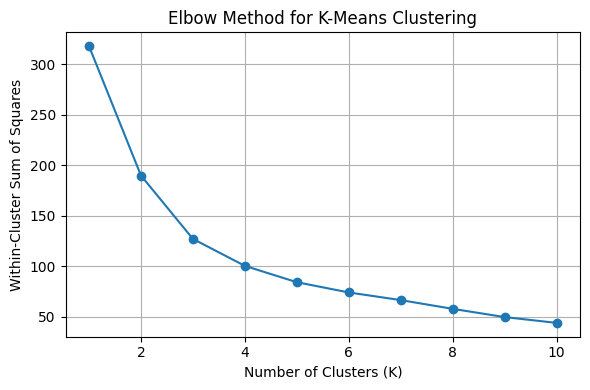

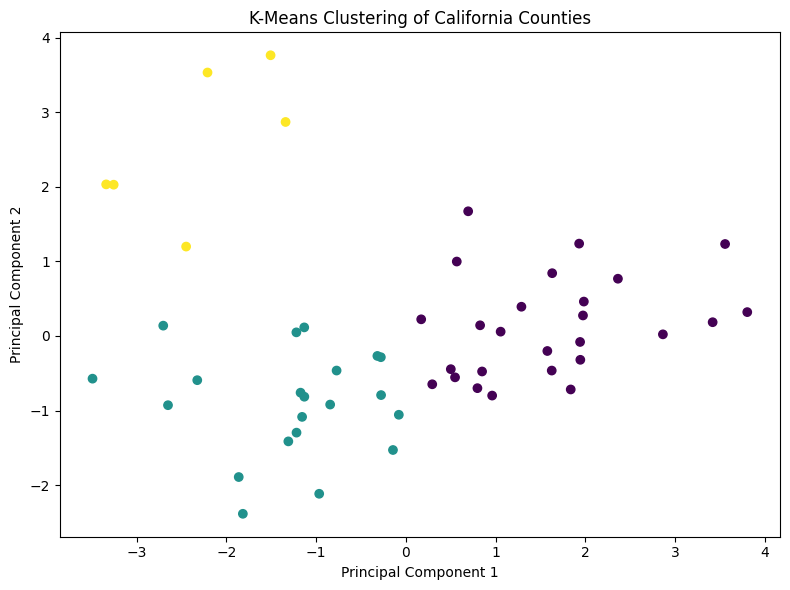

In [11]:
features = [
    "pct_bachelors_or_higher",
    "unemployment_rate",
    "median_household_income",
    "poverty_rate_all_people",
    "avg_bad_aqi_day_pct_2020_2024",
    "avg_median_aqi_2020_2024"
]

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("\nCluster counts:")
print(df["cluster"].value_counts())

print("\nCluster means:")
print(df.groupby("cluster")[features].mean().round(2))

print("\nCounties in Cluster 2:")
print(df[df["cluster"] == 2][["county"]])

# Figure 1: Elbow plot
k_values = range(1, 11)
inertia = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(1, figsize=(6, 4))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method for K-Means Clustering")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/elbow_plot.png")
plt.show()

# Figure 2: PCA plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(2, figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of California Counties")
plt.tight_layout()
plt.savefig("figures/pca_clusters.png")
plt.show()

<br><br/>

## Hypothesis Testing

We tested whether lower income California counties experience statistically worse air quality than higher income counties. Counties were split using the `lower_income_group` marker in the dataset, placing the bottom two income quartiles in the "lower-income group" and the top two in the "higher-income group".

We tested four air quality outcomes: Median AQI, percentage of bad AQI days, percentage of days where PM2.5 was the main pollutant, and percentage of days where ozone was the main pollutant.

For each outcome:

**Null hypothesis (H₀):** The mean air quality outcome is the same in lower-income and higher-income counties.

**Alternative hypothesis (Hₐ):** Lower-income counties have a worse (higher) air quality outcome than higher-income counties.

**Test statistic:** Welch t-statistic (one-sided), confirmed with a Mann-Whitney U test. Significance level α = 0.05.

In [2]:
low  = df[df["lower_income_group"] == True]
high = df[df["lower_income_group"] == False]

outcomes = {
    "avg_median_aqi_2020_2024":                    "Median AQI",
    "avg_bad_aqi_day_pct_2020_2024":               "% Bad AQI Days",
    "avg_pct_days_pm25_main_pollutant_2020_2024":  "% Days PM2.5 Main",
    "avg_pct_days_ozone_main_pollutant_2020_2024": "% Days Ozone Main",
}

rows = []
for col, label in outcomes.items():
    x_low  = low[col].dropna()
    x_high = high[col].dropna()

    t_stat, t_p_two = stats.ttest_ind(x_low, x_high, equal_var=False)
    t_p_one = t_p_two / 2 if t_stat > 0 else 1 - t_p_two / 2

    _, mwu_p = stats.mannwhitneyu(x_low, x_high, alternative="greater")

    pooled_std = np.sqrt((x_low.std(ddof=1)**2 + x_high.std(ddof=1)**2) / 2)
    d = (x_low.mean() - x_high.mean()) / pooled_std

    rows.append({
        "Outcome":        label,
        "Mean (Low-Inc)": round(x_low.mean(), 3),
        "Mean (Hi-Inc)":  round(x_high.mean(), 3),
        "t-stat":         round(t_stat, 4),
        "p (1-tail)": round(t_p_one, 4),
        "MWU p":          round(mwu_p, 4),
        "Cohen's d":      round(d, 3),
        "Sig (a=0.05)":   "Yes" if t_p_one < 0.05 else "No",
    })

results = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(results.to_string(index=False))

          Outcome  Mean (Low-Inc)  Mean (Hi-Inc)  t-stat  p (1-tail)  MWU p  Cohen's d Sig (a=0.05)
       Median AQI          50.544         48.479  0.5565      0.2901 0.1702      0.153           No
   % Bad AQI Days           7.838          6.464  0.5311      0.2989 0.0367      0.145           No
% Days PM2.5 Main          45.936         47.268 -0.2112      0.5831 0.8939     -0.059           No
% Days Ozone Main          50.288         49.234  0.1630      0.4356 0.2520      0.045           No


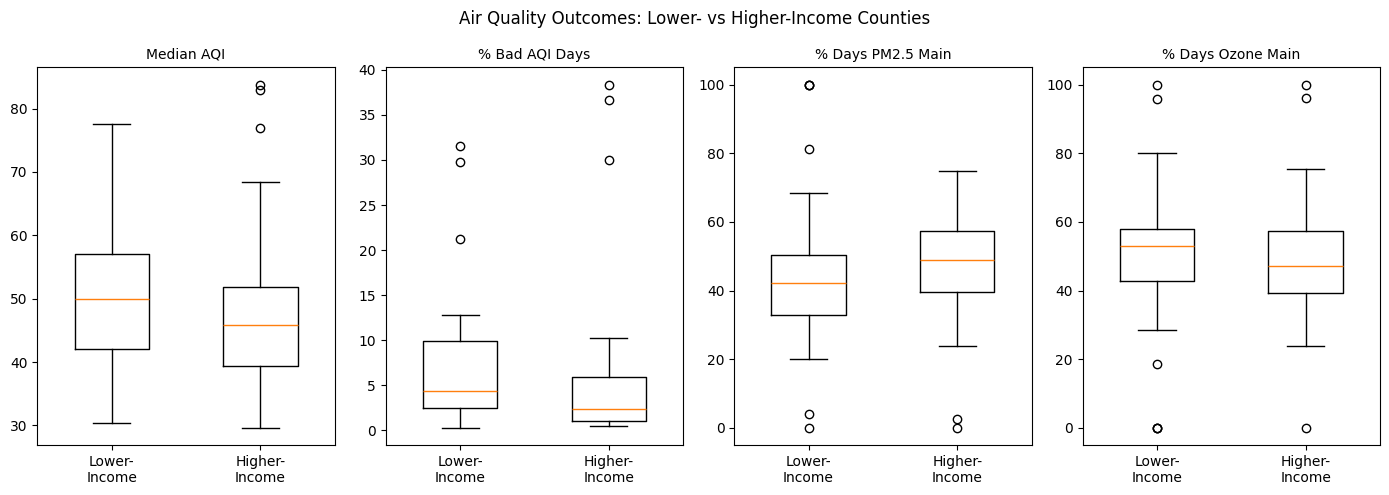

In [ ]:
fig, axes = plt.subplots(1, len(outcomes), figsize=(14, 5))

for ax, (col, label) in zip(axes, outcomes.items()):
    data = [low[col].dropna().values, high[col].dropna().values]
    ax.boxplot(data, tick_labels=["Lower-\nIncome", "Higher-\nIncome"], widths=0.5)
    ax.set_title(label, fontsize=10)

plt.suptitle("Air Quality Outcomes: Lower- vs Higher-Income Counties", fontsize=12)
plt.tight_layout()
plt.savefig("figures/hypothesis_boxplots.png")
plt.show()

#### Cohen's d

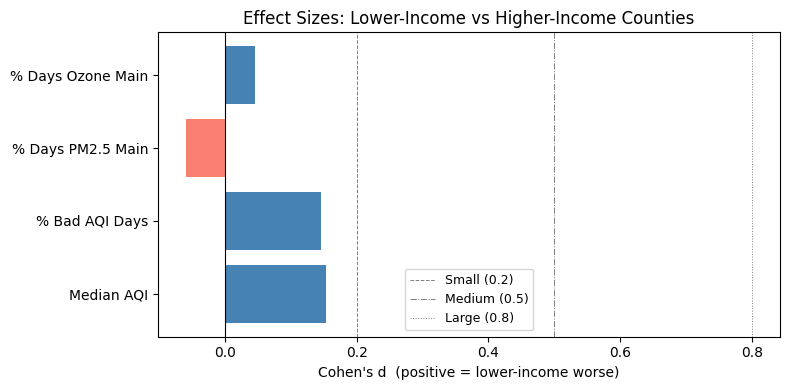

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
labels   = [r["Outcome"] for r in rows]
d_values = [r["Cohen's d"] for r in rows]
colors   = ["steelblue" if d > 0 else "salmon" for d in d_values]
ax.barh(labels, d_values, color=colors)
ax.axvline(0,   color="black", linewidth=0.8)
ax.axvline(0.2, color="gray",  linestyle="--", linewidth=0.7, label="Small (0.2)")
ax.axvline(0.5, color="gray",  linestyle="-.", linewidth=0.7, label="Medium (0.5)")
ax.axvline(0.8, color="gray",  linestyle=":",  linewidth=0.7, label="Large (0.8)")
ax.set_xlabel("Cohen's d  (positive = lower-income worse)")
ax.set_title("Effect Sizes: Lower-Income vs Higher-Income Counties")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/hypothesis_effect_sizes.png")
plt.show()

### Results

None of the four outcomes produced a statistically significant difference at α = 0.05. For Median AQI, the lower income group averaged 50.5 versus 48.5 for higher income counties, but the Welch t-test returned t = 0.557 and p = 0.290, with a Cohen's d of 0.153. For percentage of bad AQI days, the means were 7.8 versus 6.5, with t = 0.531, p = 0.299, and d = 0.145. For percentage of days where PM2.5 was the main pollutant, lower income counties actually averaged slightly lower (45.9 vs 47.3), producing t = -0.211 and a negative d of -0.059. For ozone, the difference was also not significant. (t = 0.163, p = 0.436).

The Mann-Whitney U test on percentage of bad AQI days returned p = 0.037, which crosses the threshold in isolation, but does not hold up alongside the other three non-significant results.

### Interpretation

At the county level, income group alone **does not** clearly distinguish worse or better air quality. Cohen's d values are all below 0.2, meaning the directional differences are small in practical terms. Some of California's highest income counties sit geographically close to other heavily polluted areas, which may affect any income based signal when averaged at the county scale.

<br><br/>

## Linear Regression

We fit multiple linear regression models to estimate how well socioeconomic variables predict air quality outcomes across 53 California counties. The five predictors were median household income, poverty rate, unemployment rate, percentage with a bachelor's degree or higher, and percentage with no health insurance. All predictors were standardized before fitting so their coefficients are directly comparable in magnitude.

Three separate OLS models were fit, one each for Median AQI, percentage of bad AQI days, and percentage of days where PM2.5 was the main pollutant.

**Null hypothesis (H₀):** The socioeconomic predictors have no linear relationship with the air quality outcome (all slope coefficients equal zero).

**Alternative hypothesis (Hₐ):** At least one socioeconomic predictor has a nonzero linear relationship with the air quality outcome.

**Test statistic:** F-statistic from the omnibus F-test. Individual predictors are evaluated with t-statistics on each coefficient. Significance level α = 0.05.

In [5]:
predictors = [
    "median_household_income",
    "poverty_rate_all_people",
    "unemployment_rate",
    "pct_bachelors_or_higher",
    "pct_no_health_insurance",
]

reg_outcomes = {
    "avg_median_aqi_2020_2024":                   "Median AQI",
    "avg_bad_aqi_day_pct_2020_2024":              "% Bad AQI Days",
    "avg_pct_days_pm25_main_pollutant_2020_2024": "% Days PM2.5 Main",
}

reg_df   = df[predictors + list(reg_outcomes.keys())].dropna().copy()
X_scaled = StandardScaler().fit_transform(reg_df[predictors])
X_df     = pd.DataFrame(X_scaled, columns=predictors, index=reg_df.index)
X        = sm.add_constant(X_df)

models = {}
for col, label in reg_outcomes.items():
    model = sm.OLS(reg_df[col], X).fit()
    models[col] = model
    print(f"\n{'='*55}")
    print(f"Outcome: {label}")
    print(f"  R²      = {model.rsquared:.4f}")
    print(f"  Adj. R² = {model.rsquared_adj:.4f}")
    print(f"  F-stat  = {model.fvalue:.4f}  (p = {model.f_pvalue:.4f})")
    print(model.summary())


Outcome: Median AQI
  R²      = 0.1561
  Adj. R² = 0.0663
  F-stat  = 1.7387  (p = 0.1443)
                               OLS Regression Results                               
Dep. Variable:     avg_median_aqi_2020_2024   R-squared:                       0.156
Model:                                  OLS   Adj. R-squared:                  0.066
Method:                       Least Squares   F-statistic:                     1.739
Date:                      Sun, 07 Jun 2026   Prob (F-statistic):              0.144
Time:                              20:10:49   Log-Likelihood:                -208.08
No. Observations:                        53   AIC:                             428.2
Df Residuals:                            47   BIC:                             440.0
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                              coef    std err          t  

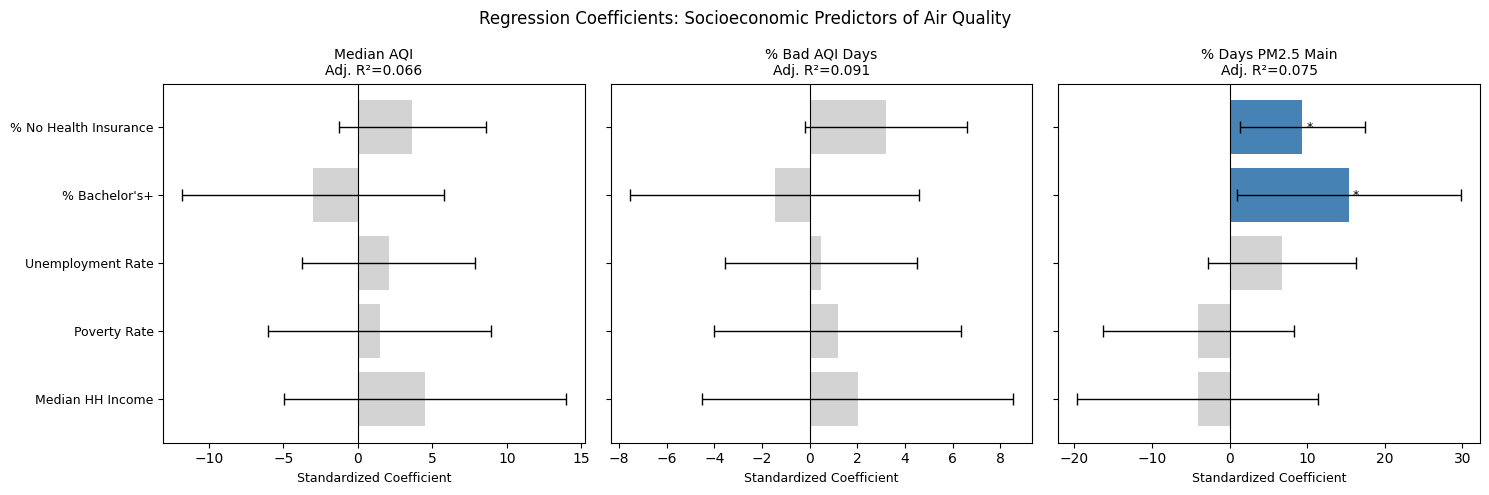

In [6]:
pred_labels = {
    "median_household_income": "Median HH Income",
    "poverty_rate_all_people": "Poverty Rate",
    "unemployment_rate":       "Unemployment Rate",
    "pct_bachelors_or_higher": "% Bachelor's+",
    "pct_no_health_insurance": "% No Health Insurance",
}

# Figure 3: Coefficient plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (col, label) in zip(axes, reg_outcomes.items()):
    model = models[col]
    coef  = model.params.drop("const")
    conf  = model.conf_int().drop("const")
    pvals = model.pvalues.drop("const")

    y_pos  = np.arange(len(coef))
    colors = ["steelblue" if p < 0.05 else "lightgray" for p in pvals]

    ax.barh(y_pos, coef.values, color=colors,
            xerr=[coef.values - conf[0].values, conf[1].values - coef.values],
            capsize=4, error_kw={"linewidth": 1})
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([pred_labels[v] for v in predictors], fontsize=9)
    ax.set_title(f"{label}\nAdj. R²={model.rsquared_adj:.3f}", fontsize=10)
    ax.set_xlabel("Standardized Coefficient", fontsize=9)

    for i, (c, p) in enumerate(zip(coef.values, pvals)):
        star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        if star:
            ax.text(c + (0.5 if c >= 0 else -0.5), i, star,
                    va="center", ha="left" if c >= 0 else "right", fontsize=9)

plt.suptitle("Regression Coefficients: Socioeconomic Predictors of Air Quality", fontsize=12)
plt.tight_layout()
plt.savefig("figures/regression_coefficients.png")
plt.show()

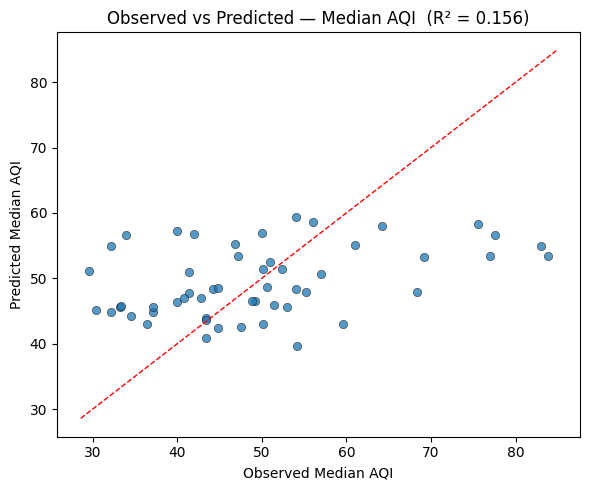

In [7]:
# Figure 4: Observed vs Predicted (Median AQI)
primary = models["avg_median_aqi_2020_2024"]
fitted  = primary.fittedvalues
y_true  = reg_df["avg_median_aqi_2020_2024"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true, fitted, alpha=0.75, edgecolors="k", linewidths=0.4)
lim = [min(y_true.min(), fitted.min()) - 1, max(y_true.max(), fitted.max()) + 1]
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlabel("Observed Median AQI")
ax.set_ylabel("Predicted Median AQI")
ax.set_title(f"Observed vs Predicted — Median AQI  (R² = {primary.rsquared:.3f})")
plt.tight_layout()
plt.savefig("figures/regression_observed_vs_predicted.png")
plt.show()

### Results

For Median AQI, the model produced an R² of 0.156 and an adjusted R² of 0.069. The F-statistic was 1.74 with p = 0.144, meaning the predictors as a set did not significantly explain variation in median AQI. No individual predictor reached significance, though percentage with no health insurance had the largest positive coefficient (3.64).

For percentage of bad AQI days, the model explained slightly more variance with R² = 0.178 and adjusted R² = 0.094. The F-test returned F = 2.04 with p = 0.090, again non-significant. Percentage with no health insurance had the largest coefficient (3.21, p = 0.065), narrowly missing significance.

For percentage of days where PM2.5 was the main pollutant, R² was 0.164 with adjusted R² of 0.076 and F = 1.84 with p = 0.123. Two predictors reached significance at α = 0.05: percentage with a bachelor's degree or higher (β = 15.40, t = 2.15, p = 0.037) and percentage with no health insurance (β = 9.38, t = 2.33, p = 0.024).

### Interpretation

The omnibus F-tests are all non-significant, meaning the five socioeconomic variables as a group **do not** reliably predict county-level AQI. Adjusted R² values below 0.10 across all three models confirm they explain little of the variance.

As with the hypothesis tests, county-level aggregation is likely masking the relationship between pollution exposure and income that would be more visible at geographic measures.

<br><br/>

## Overall Analyses Interpretation

...

<br><br/>

## Shortcomings

...